<a href="https://colab.research.google.com/github/00ayeshazahra/WWTP-Predictive-Maintainance/blob/main/Pump_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import glob
import os

BASE_PATH = "/content/drive/MyDrive/Xylem Pump/Pump1/"

# Define global TIME_COL and column name aliases for consistency
TIME_COL = "Time (yyyy/mm/dd hh:mm:ss)"
current_col           = "Pump Current (A)"
frequency_col         = "Frequency (Hz)"
pump_run_col          = "Pump Run (h)"
duty_col              = "Pump Duty Rate (%)"
starts_col            = "Starts per 24h"
bearing_col           = "Main Bearing Temp (°C)"
stator_col            = "Stator Phase Temp (°C)"
pem_col               = "PEM Temp (°C)"
vib_x_col             = "Vibration X (mm/s)"
vib_y_col             = "Vibration Y (mm/s)"
vib_z_col             = "Vibration Z (mm/s)"


def _load_single_csv_file(filename, sensor_column_name, base_path=BASE_PATH):
    file_path = os.path.join(base_path, filename)

    df = pd.read_csv(
        file_path,
        sep=';',
        decimal=',',
        header=8,
        usecols=[0, 1],
        parse_dates=[0],
        encoding='cp437'
    )

    # Explicitly rename the columns. The first column is TIME_COL, the second is the sensor data.
    df.columns = [TIME_COL, sensor_column_name]

    # Safeguard for timestamp parsing
    df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")

    # Replace negative error values with None
    df.iloc[:, 1] = df.iloc[:, 1].where(df.iloc[:, 1] >= 0, other=None)

    # Remove invalid timestamps
    df = df.dropna(subset=[TIME_COL])

    # Remove values more than 50% away from the mean (filters spikes & dropouts)
    #mean_val = df[sensor_column_name].mean()
    #df = df[(df[sensor_column_name] >= mean_val * 1) & (df[sensor_column_name] <= mean_val * 1)]

    # Sort chronologically
    df = df.sort_values(TIME_COL).reset_index(drop=True)

    print(f"Loaded {filename} as '{sensor_column_name}': {len(df)} rows")

    return df

# Load all sensor files using the new function signature
current_df           = _load_single_csv_file("PumpCurrent.csv", current_col)
frequency_df         = _load_single_csv_file("Frequency.csv", frequency_col)
pump_run_df          = _load_single_csv_file("PumpRun.csv", pump_run_col)
duty_rate_df         = _load_single_csv_file("PumpDutyRate.csv", duty_col)
starts24h_df         = _load_single_csv_file("Starts24h.csv", starts_col)
main_bearing_temp_df = _load_single_csv_file("MainBearingTemp.csv", bearing_col)
stator_temp_df       = _load_single_csv_file("StatorPhaseTemp.csv", stator_col)
pem_temp_df          = _load_single_csv_file("PumpElectronicModuleTemp.csv", pem_col)
vibration_x_df       = _load_single_csv_file("VibrationX.csv", vib_x_col)
vibration_y_df       = _load_single_csv_file("VibrationY.csv", vib_y_col)
vibration_z_df       = _load_single_csv_file("VibrationZ.csv", vib_z_col)

# Merge all into combined_df
combined_df = current_df
for df_to_merge in [frequency_df, pump_run_df, duty_rate_df, starts24h_df,
                    main_bearing_temp_df, stator_temp_df, pem_temp_df, # Added stator_temp_df to the merge list
                    vibration_x_df, vibration_y_df, vibration_z_df]:
    combined_df = pd.merge(combined_df, df_to_merge, on=TIME_COL, how="outer")

combined_df = combined_df.sort_values(TIME_COL).reset_index(drop=True)
print("All files loaded and combined successfully!")

# Column name aliases are already defined at the top of the cell and used within the _load_single_csv_file function.
# These redundant lines are kept for consistency with previous notebook structure if needed, but are no longer strictly necessary.
# current_col  = "Pump Current (A)"
# frequency_col = "Frequency (Hz)"
# pump_run_col  = "Pump Run (h)"
# duty_col      = "Pump Duty Rate (%)"
# starts_col    = "Starts per 24h"
# bearing_col   = "Main Bearing Temp (°C)"
# pem_col       = "PEM Temp (°C)"
# vib_x_col     = "Vibration X (mm/s)"
# vib_y_col     = "Vibration Y (mm/s)"
# vib_z_col     = "Vibration Z (mm/s)"

Loaded PumpCurrent.csv as 'Pump Current (A)': 683 rows
Loaded Frequency.csv as 'Frequency (Hz)': 683 rows
Loaded PumpRun.csv as 'Pump Run (h)': 683 rows
Loaded PumpDutyRate.csv as 'Pump Duty Rate (%)': 683 rows
Loaded Starts24h.csv as 'Starts per 24h': 683 rows
Loaded MainBearingTemp.csv as 'Main Bearing Temp (°C)': 683 rows
Loaded StatorPhaseTemp.csv as 'Stator Phase Temp (°C)': 683 rows
Loaded PumpElectronicModuleTemp.csv as 'PEM Temp (°C)': 683 rows
Loaded VibrationX.csv as 'Vibration X (mm/s)': 683 rows
Loaded VibrationY.csv as 'Vibration Y (mm/s)': 683 rows
Loaded VibrationZ.csv as 'Vibration Z (mm/s)': 683 rows
All files loaded and combined successfully!


In [ ]:
SENSOR_COLS = [
    current_col, frequency_col, pump_run_col, duty_col, starts_col,
    bearing_col, pem_col, vib_x_col, vib_y_col, vib_z_col
]

LIMITS = {
    current_col: {"high": 257.4, "very_high": 280.8},
    duty_col:    {"high": 90},
    starts_col:  {"high": 10},
    vib_x_col:   {"high": 7.1},
}

combined_df[TIME_COL] = pd.to_datetime(combined_df[TIME_COL])
mp_df = combined_df[[TIME_COL] + SENSOR_COLS].copy()

# Explicitly handle NaN values in sensor columns before further processing
# This is crucial for models like Matrix Profile, LSTM Autoencoder, and EWMA
for col in SENSOR_COLS:
    # Interpolate missing values in each sensor column
    mp_df[col] = mp_df[col].interpolate(method='linear', limit_direction='both')
    # Fill any remaining NaNs (e.g., if column was entirely NaN or had leading/trailing NaNs) with the mean
    if mp_df[col].isnull().any():
        mp_df[col] = mp_df[col].fillna(mp_df[col].mean())

In [ ]:
correlation_table = combined_df.corr(method="pearson")
correlation_table.round(3)

,Time (yyyy/mm/dd hh:mm:ss),Pump Current (A),Frequency (Hz),Pump Run (h),Pump Duty Rate (%),Starts per 24h,Main Bearing Temp (°C),Stator Phase Temp (°C),PEM Temp (°C),Vibration X (mm/s),Vibration Y (mm/s),Vibration Z (mm/s)
Time (yyyy/mm/dd hh:mm:ss),1.000,0.128,0.086,-0.007,-0.044,0.056,0.024,0.067,0.018,-0.094,0.171,-0.091
Pump Current (A),0.128,1.000,0.990,0.405,0.223,0.072,0.531,0.547,0.537,0.397,0.355,0.296
Frequency (Hz),0.086,0.990,1.000,0.469,0.261,0.043,0.581,0.600,0.588,0.372,0.335,0.304
Pump Run (h),-0.007,0.405,0.469,1.000,0.546,0.210,0.935,0.956,0.876,0.105,0.008,0.210
Pump Duty Rate (%),-0.044,0.223,0.261,0.546,1.000,0.320,0.533,0.528,0.528,0.149,0.016,0.364
Starts per 24h,0.056,0.072,0.043,0.210,0.320,1.000,0.198,0.160,0.140,0.113,-0.099,0.215
Main Bearing Temp (°C),0.024,0.531,0.581,0.935,0.533,0.198,1.000,0.988,0.978,0.204,0.127,0.309
Stator Phase Temp (°C),0.067,0.547,0.600,0.956,0.528,0.160,0.988,1.000,0.967,0.179,0.124,0.260
PEM Temp (°C),0.018,0.537,0.588,0.876,0.528,0.140,0.978,0.967,1.000,0.244,0.190,0.337
Vibration X (mm/s),-0.094,0.397,0.372,0.105,0.149,0.113,0.204,0.179,0.244,1.000,0.616,0.644


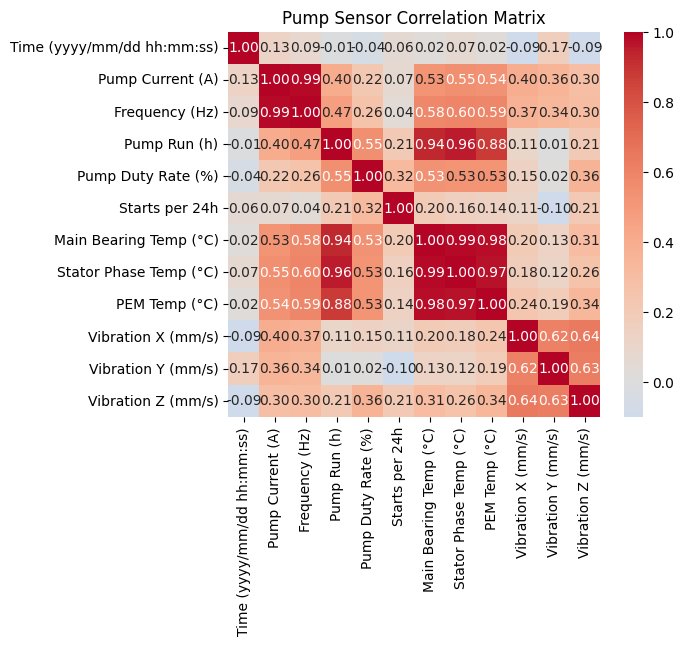

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(
    correlation_table,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Pump Sensor Correlation Matrix")
plt.show()

In [ ]:
import stumpy
import numpy as np

# Matrix Profile
# Window = roughly 7 days of data.
# Adjust WINDOW_ROWS to match your actual sampling rate:
#   e.g. 1 reading/hour  → 7*24 = 168
#        1 reading/15min → 7*96 = 672
#        1 reading/day   → 7

WINDOW_ROWS = 7   # ← adjust this to your sampling rate

print(f"Window size: {WINDOW_ROWS} rows")
print("Computing per-sensor matrix profiles...")

per_sensor_mp = {}
for col in SENSOR_COLS:
    series = mp_df[col].values.astype(float)
    mp_result = stumpy.stump(series, m=WINDOW_ROWS)
    per_sensor_mp[col] = mp_result[:, 0]   # distance profile only
    print(f"  ✓ {col}")

# ── Multivariate profile across all sensors simultaneously ───────────────────
print("\nComputing multivariate profile (mSTAMP)...")
data_matrix = mp_df[SENSOR_COLS].values.T.astype(float)
# shape: (n_sensors, n_timepoints)

mp_multi, ip_multi = stumpy.mstump(data_matrix, m=WINDOW_ROWS)
# mp_multi shape: (n_sensors, n_timepoints - m + 1)
# Sum across sensors for a single combined anomaly score
combined_profile = mp_multi.sum(axis=0)

print("  ✓ Multivariate profile complete")
print(f"\nProfile length: {len(combined_profile)} points")

# ── Normalise combined profile to 0-1 for easy thresholding ─────────────────
profile_norm = (combined_profile - combined_profile.min()) / \
               (combined_profile.max() - combined_profile.min())

# ── Timestamps aligned to profile length ────────────────────────────────────
# Matrix profile output is shorter than input by (window - 1)
profile_times = mp_df[TIME_COL].values[:len(combined_profile)]

# ── Threshold: flag anything above mean + 2σ ────────────────────────────────
THRESHOLD_SIGMA = 2.0
mean_p = combined_profile.mean()
std_p  = combined_profile.std()
threshold = mean_p + THRESHOLD_SIGMA * std_p
threshold_norm = (threshold - combined_profile.min()) / \
                 (combined_profile.max() - combined_profile.min())

# ── Find top discords (most anomalous windows) ───────────────────────────────
N_DISCORDS = 100
discord_indices = np.argsort(combined_profile)[-N_DISCORDS:][::-1]
discord_times   = profile_times[discord_indices]

print(f"\nTop {N_DISCORDS} anomalous windows:")
for rank, (idx, t) in enumerate(zip(discord_indices, discord_times)):
    t_str = pd.Timestamp(t).strftime("%Y-%m-%d")
    print(f"  #{rank+1}  {t_str}  (score: {combined_profile[idx]:.2f})")

Window size: 7 rows
Computing per-sensor matrix profiles...
  ✓ Pump Current (A)
  ✓ Frequency (Hz)
  ✓ Pump Run (h)
  ✓ Pump Duty Rate (%)
  ✓ Starts per 24h
  ✓ Main Bearing Temp (°C)
  ✓ PEM Temp (°C)
  ✓ Vibration X (mm/s)
  ✓ Vibration Y (mm/s)
  ✓ Vibration Z (mm/s)

Computing multivariate profile (mSTAMP)...
  ✓ Multivariate profile complete

Profile length: 677 points

Top 100 anomalous windows:
  #1  2025-01-17  (score: 18.67)
  #2  2026-02-02  (score: 17.85)
  #3  2024-08-02  (score: 17.80)
  #4  2025-04-14  (score: 17.72)
  #5  2025-03-05  (score: 17.52)
  #6  2025-01-18  (score: 17.41)
  #7  2024-12-01  (score: 17.37)
  #8  2025-04-13  (score: 17.23)
  #9  2026-02-26  (score: 17.17)
  #10  2024-11-25  (score: 17.06)
  #11  2025-04-15  (score: 17.05)
  #12  2025-03-03  (score: 16.97)
  #13  2024-11-24  (score: 16.93)
  #14  2024-07-20  (score: 16.92)
  #15  2026-02-01  (score: 16.89)
  #16  2026-02-03  (score: 16.88)
  #17  2025-04-12  (score: 16.87)
  #18  2024-07-18  (scor

In [ ]:
# ── ISOLATION FOREST ────────────────────────────────────────────────────────
# Trains on the full dataset unsupervised.
# No window size needed — works on individual timestep feature vectors.
# Contamination = expected fraction of anomalies in the data (adjust 0.01–0.05)

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

CONTAMINATION = 0.05   # ← assume ~5% of readings are anomalous
N_DISCORDS    = 100
THRESHOLD_SIGMA = 2.0

print("Preparing features for Isolation Forest...")

# ── Feature matrix: all sensors at each timestep ─────────────────────────────
X = mp_df[SENSOR_COLS].values.astype(float)

# ── Standardise (IF is scale-sensitive across mixed units) ───────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Fit Isolation Forest ──────────────────────────────────────────────────────
print("Fitting Isolation Forest...")
iso = IsolationForest(
    n_estimators=200,        # more trees = more stable scores
    contamination=CONTAMINATION,
    random_state=42,
    n_jobs=-1                # use all CPU cores
)
iso.fit(X_scaled)

# ── Score each timestep ───────────────────────────────────────────────────────
# decision_function returns: more negative = more anomalous
# We negate so that HIGH score = anomalous (consistent with Matrix Profile)
if_raw_scores  = -iso.decision_function(X_scaled)
if_labels      = iso.predict(X_scaled)   # -1 = anomaly, +1 = normal

# ── Normalise to 0-1 ─────────────────────────────────────────────────────────
if_norm = (if_raw_scores - if_raw_scores.min()) / \
          (if_raw_scores.max() - if_raw_scores.min())

# ── Timestamps (full length — IF operates per timestep, no window offset) ────
if_times = mp_df[TIME_COL].values

# ── Threshold ────────────────────────────────────────────────────────────────
mean_if   = if_raw_scores.mean()
std_if    = if_raw_scores.std()
threshold_if      = mean_if + THRESHOLD_SIGMA * std_if
threshold_if_norm = (threshold_if - if_raw_scores.min()) / \
                    (if_raw_scores.max() - if_raw_scores.min())

# ── Top anomalous timesteps ───────────────────────────────────────────────────
discord_indices_if = np.argsort(if_raw_scores)[-N_DISCORDS:][::-1]
discord_times_if   = if_times[discord_indices_if]

print(f"\nTop {N_DISCORDS} anomalous timesteps (Isolation Forest):")
for rank, (idx, t) in enumerate(zip(discord_indices_if, discord_times_if)):
    t_str = pd.Timestamp(t).strftime("%Y-%m-%d")
    print(f"  #{rank+1}  {t_str}  (score: {if_raw_scores[idx]:.4f})")

print(f"\nTotal flagged anomalies : {(if_labels == -1).sum()} / {len(if_labels)} timesteps")
print(f"Anomaly rate            : {(if_labels == -1).mean()*100:.1f}%")

Preparing features for Isolation Forest...
Fitting Isolation Forest...

Top 100 anomalous timesteps (Isolation Forest):
  #1  2024-10-27  (score: 0.2629)
  #2  2025-06-04  (score: 0.2561)
  #3  2024-10-26  (score: 0.2526)
  #4  2024-10-22  (score: 0.2455)
  #5  2024-11-03  (score: 0.2452)
  #6  2024-10-25  (score: 0.2411)
  #7  2024-11-02  (score: 0.2390)
  #8  2025-06-03  (score: 0.2026)
  #9  2024-10-28  (score: 0.1724)
  #10  2024-11-04  (score: 0.1293)
  #11  2024-10-29  (score: 0.1039)
  #12  2024-10-21  (score: 0.0896)
  #13  2024-10-23  (score: 0.0804)
  #14  2025-08-04  (score: 0.0759)
  #15  2025-09-09  (score: 0.0604)
  #16  2025-08-10  (score: 0.0539)
  #17  2024-10-17  (score: 0.0420)
  #18  2025-06-05  (score: 0.0393)
  #19  2025-05-04  (score: 0.0345)
  #20  2025-08-23  (score: 0.0343)
  #21  2024-07-08  (score: 0.0317)
  #22  2025-08-24  (score: 0.0200)
  #23  2026-02-08  (score: 0.0169)
  #24  2026-02-26  (score: 0.0151)
  #25  2024-07-07  (score: 0.0139)
  #26  2026-02

In [ ]:
# ── LSTM AUTOENCODER ─────────────────────────────────────────────────────────
# Learns "normal" temporal patterns from a rolling window.
# High reconstruction error = the pattern looks nothing like normal → anomaly.
# Requires tensorflow; install with: pip install tensorflow --quiet

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, RepeatVector,
                                     TimeDistributed, Dense)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

print(f"TensorFlow version: {tf.__version__}")

# ─────────────────────────────────────────────────────────────────────────────
# Config
# ─────────────────────────────────────────────────────────────────────────────
WINDOW_ROWS     = 7      # ← same as your Matrix Profile window
LATENT_DIM      = 32     # bottleneck size — smaller = stricter normal model
EPOCHS          = 50
BATCH_SIZE      = 64
VALIDATION_SPLIT= 0.1
THRESHOLD_SIGMA = 2.0
N_DISCORDS      = 100

# ─────────────────────────────────────────────────────────────────────────────
# 1. Scale features
# ─────────────────────────────────────────────────────────────────────────────
scaler_lstm = StandardScaler()
X_scaled = scaler_lstm.fit_transform(mp_df[SENSOR_COLS].values.astype(float))

n_timesteps = len(X_scaled)
n_features  = len(SENSOR_COLS)

# ─────────────────────────────────────────────────────────────────────────────
# 2. Build sliding windows  shape: (n_windows, WINDOW_ROWS, n_features)
# ─────────────────────────────────────────────────────────────────────────────
print("Building sliding windows...")

def make_windows(data, window):
    return np.stack([data[i:i+window] for i in range(len(data) - window + 1)])

X_windows = make_windows(X_scaled, WINDOW_ROWS)
print(f"  Windows shape: {X_windows.shape}")

# ─────────────────────────────────────────────────────────────────────────────
# 3. Build LSTM Autoencoder
# ─────────────────────────────────────────────────────────────────────────────
print("Building model...")

inp     = Input(shape=(WINDOW_ROWS, n_features))
encoded = LSTM(LATENT_DIM, activation="tanh", return_sequences=False)(inp)
decoded = RepeatVector(WINDOW_ROWS)(encoded)
decoded = LSTM(LATENT_DIM, activation="tanh", return_sequences=True)(decoded)
out     = TimeDistributed(Dense(n_features))(decoded)

autoencoder = Model(inputs=inp, outputs=out)
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

# ─────────────────────────────────────────────────────────────────────────────
# 4. Train (on all data — unsupervised, learns "normal" fingerprint)
# ─────────────────────────────────────────────────────────────────────────────
print("\nTraining LSTM Autoencoder...")
early_stop = EarlyStopping(monitor="val_loss", patience=5,
                           restore_best_weights=True, verbose=1)

history = autoencoder.fit(
    X_windows, X_windows,          # input = target (reconstruction)
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks=[early_stop],
    shuffle=True,
    verbose=1
)

# ─────────────────────────────────────────────────────────────────────────────
# 5. Reconstruction error per window = anomaly score
# ─────────────────────────────────────────────────────────────────────────────
print("\nScoring all windows...")
X_reconstructed = autoencoder.predict(X_windows, batch_size=BATCH_SIZE, verbose=0)

# Mean squared error per window
recon_errors = np.mean(np.square(X_windows - X_reconstructed), axis=(1, 2))

# ── Normalise ─────────────────────────────────────────────────────────────────
lstm_norm = (recon_errors - recon_errors.min()) / \
            (recon_errors.max() - recon_errors.min())

# ── Timestamps (offset by window − 1, same as Matrix Profile) ────────────────
lstm_times = mp_df[TIME_COL].values[:len(recon_errors)]

# ── Threshold ─────────────────────────────────────────────────────────────────
mean_re         = recon_errors.mean()
std_re          = recon_errors.std()
threshold_lstm  = mean_re + THRESHOLD_SIGMA * std_re
threshold_lstm_norm = (threshold_lstm - recon_errors.min()) / \
                      (recon_errors.max() - recon_errors.min())

# ── Top anomalous windows ──────────────────────────────────────────────────────
discord_indices_lstm = np.argsort(recon_errors)[-N_DISCORDS:][::-1]
discord_times_lstm   = lstm_times[discord_indices_lstm]

print(f"\nTop {N_DISCORDS} anomalous windows (LSTM Autoencoder):")
for rank, (idx, t) in enumerate(zip(discord_indices_lstm, discord_times_lstm)):
    t_str = pd.Timestamp(t).strftime("%Y-%m-%d")
    print(f"  #{rank+1}  {t_str}  (reconstruction error: {recon_errors[idx]:.6f})")

print(f"\nTotal flagged anomalies : {(recon_errors > threshold_lstm).sum()} windows")
print(f"Anomaly rate            : {(recon_errors > threshold_lstm).mean()*100:.1f}%")

TensorFlow version: 2.20.0
Building sliding windows...
  Windows shape: (677, 7, 10)
Building model...


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 7, 10)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 32)             │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_4 (RepeatVector)  │ (None, 7, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 7, 32)          │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 7, 10)          │           330 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,154 (55.29 KB)

 Trainable params: 14,154 (55.29 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM Autoencoder...
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 166ms/step - loss: 1.0377 - val_loss: 0.3343
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.9393 - val_loss: 0.2994
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.8435 - val_loss: 0.2651
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.7515 - val_loss: 0.2366
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.6814 - val_loss: 0.2224
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.6354 - val_loss: 0.2166
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.6027 - val_loss: 0.2121
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.5786 - val_loss: 0.2078
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.5604 - val_loss: 0.2029
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.5452 - val_loss: 0.1982
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.5324 - val_loss: 0.1931
Epoch 12/50
10/10 ━━━━━━━━━━━━━

In [ ]:
# ── CUSUM & EWMA ─────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

EWMA_LAMBDA     = 0.1
CUSUM_K         = 0.5
THRESHOLD_SIGMA = 2.0
N_DISCORDS      = 100

print("Computing CUSUM & EWMA...")

scaler_spc = StandardScaler()
X_spc = scaler_spc.fit_transform(mp_df[SENSOR_COLS].values.astype(float))
n_steps, n_sensors = X_spc.shape

# ── EWMA ──────────────────────────────────────────────────────────────────────
ewma_scores = np.zeros((n_steps, n_sensors))
for j in range(n_sensors):
    z       = X_spc[:, j]
    ewma    = np.zeros(n_steps)
    ewma[0] = z[0]
    for i in range(1, n_steps):
        ewma[i] = EWMA_LAMBDA * z[i] + (1 - EWMA_LAMBDA) * ewma[i-1]
    sigma_ewma           = np.sqrt(EWMA_LAMBDA / (2 - EWMA_LAMBDA))
    ucl                  =  THRESHOLD_SIGMA * sigma_ewma
    lcl                  = -THRESHOLD_SIGMA * sigma_ewma
    ewma_scores[:, j]    = np.maximum(ewma - ucl, 0) + np.maximum(lcl - ewma, 0)

ewma_combined = ewma_scores.sum(axis=1)

# ── CUSUM ─────────────────────────────────────────────────────────────────────
cusum_scores = np.zeros((n_steps, n_sensors))
for j in range(n_sensors):
    z     = X_spc[:, j]
    S_pos = np.zeros(n_steps)
    S_neg = np.zeros(n_steps)
    for i in range(1, n_steps):
        S_pos[i]          = max(0, S_pos[i-1] + z[i] - CUSUM_K)
        S_neg[i]          = max(0, S_neg[i-1] - z[i] - CUSUM_K)
    cusum_scores[:, j]    = np.maximum(S_pos, S_neg)

cusum_combined = cusum_scores.sum(axis=1)

# ── Normalise & thresholds ────────────────────────────────────────────────────
def normalise(arr):
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-9)

def norm_threshold(arr, sigma=THRESHOLD_SIGMA):
    t = arr.mean() + sigma * arr.std()
    return (t - arr.min()) / (arr.max() - arr.min() + 1e-9)

ewma_norm            = normalise(ewma_combined)
cusum_norm           = normalise(cusum_combined)
threshold_ewma_norm  = norm_threshold(ewma_combined)
threshold_cusum_norm = norm_threshold(cusum_combined)
spc_times            = mp_df[TIME_COL].values

# ── Top discords ──────────────────────────────────────────────────────────────
def top_discords(raw, times, n=N_DISCORDS):
    idx = np.argsort(raw)[-n:][::-1]
    return idx, times[idx]

discord_indices_ewma,  discord_times_ewma  = top_discords(ewma_combined,  spc_times)
discord_indices_cusum, discord_times_cusum = top_discords(cusum_combined, spc_times)

print("Top anomalous timesteps (EWMA):")
for rank, (idx, t) in enumerate(zip(discord_indices_ewma, discord_times_ewma)):
    print(f"  #{rank+1}  {pd.Timestamp(t).strftime('%Y-%m-%d')}  (score: {ewma_combined[idx]:.4f})")

print("\nTop anomalous timesteps (CUSUM):")
for rank, (idx, t) in enumerate(zip(discord_indices_cusum, discord_times_cusum)):
    print(f"  #{rank+1}  {pd.Timestamp(t).strftime('%Y-%m-%d')}  (score: {cusum_combined[idx]:.4f})")

print("\n✓ CUSUM & EWMA complete")

Computing CUSUM & EWMA...
Top anomalous timesteps (EWMA):
  #1  2024-11-03  (score: 15.4493)
  #2  2024-10-27  (score: 15.4038)
  #3  2024-10-28  (score: 14.7816)
  #4  2024-11-04  (score: 14.6648)
  #5  2024-10-29  (score: 13.7684)
  #6  2024-11-05  (score: 13.0829)
  #7  2024-11-02  (score: 12.5053)
  #8  2024-10-30  (score: 12.4497)
  #9  2024-10-26  (score: 12.2057)
  #10  2024-11-06  (score: 11.8332)
  #11  2024-10-31  (score: 11.0683)
  #12  2024-11-07  (score: 10.6388)
  #13  2024-11-01  (score: 10.1696)
  #14  2024-11-08  (score: 9.5581)
  #15  2024-10-25  (score: 8.7798)
  #16  2024-11-09  (score: 8.6514)
  #17  2024-11-10  (score: 7.7997)
  #18  2024-11-11  (score: 7.5058)
  #19  2024-07-08  (score: 7.2432)
  #20  2024-07-09  (score: 7.2028)
  #21  2024-07-10  (score: 7.1811)
  #22  2024-07-02  (score: 7.1327)
  #23  2024-07-13  (score: 7.0567)
  #24  2024-07-07  (score: 7.0411)
  #25  2024-07-14  (score: 7.0372)
  #26  2024-07-12  (score: 7.0155)
  #27  2024-07-01  (score: 6

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

MAINTENANCE_DATES = [
    pd.Timestamp("2025-08-21"),
    # pd.Timestamp("YYYY-MM-DD"),  # add more here
]
DEGRADATION_DAYS = 90    # days before maintenance where RUL counts down
WINDOW_ROWS      = 7     # rolling input window — keep same as other models
EPOCHS           = 80
BATCH_SIZE       = 64
RUL_MAX          = DEGRADATION_DAYS
ALERT_RED        = 14    # days — urgent
ALERT_ORANGE     = 30    # days — warning

print(f"TensorFlow : {tf.__version__}")
print(f"Events     : {[str(d.date()) for d in MAINTENANCE_DATES]}")

# ── 1. Build RUL labels ───────────────────────────────────────────────────────
rul_labels = np.full(len(mp_df), float(RUL_MAX))
for maint_date in MAINTENANCE_DATES:
    window_start = maint_date - pd.Timedelta(days=DEGRADATION_DAYS)
    for i, ts in enumerate(mp_df[TIME_COL]):
        ts = pd.Timestamp(ts)
        if window_start <= ts <= maint_date:
            rul_labels[i] = min(rul_labels[i], float((maint_date - ts).days))

rul_labels_norm = rul_labels / RUL_MAX
print(f"Labelled degradation timesteps: {(rul_labels < RUL_MAX).sum()} / {len(rul_labels)}")

# ── 2. Scale features ─────────────────────────────────────────────────────────
# Handle NaNs in the sensor data before scaling and passing to the RUL model
mp_df_clean_rul = mp_df[SENSOR_COLS].astype(float).copy()
mp_df_clean_rul = mp_df_clean_rul.interpolate(method='linear', limit_direction='both', axis=0)
mp_df_clean_rul = mp_df_clean_rul.ffill().bfill() # ensure no remaining NaNs

scaler_rul = StandardScaler()
X_rul      = scaler_rul.fit_transform(mp_df_clean_rul.values)

# ── 3. Sliding windows ────────────────────────────────────────────────────────
X_windows = np.stack([X_rul[i:i+WINDOW_ROWS] for i in range(len(X_rul) - WINDOW_ROWS + 1)])
y_windows = rul_labels_norm[WINDOW_ROWS - 1:]
rul_times = mp_df[TIME_COL].values[WINDOW_ROWS - 1:]

# ── 4. Train/test split on maintenance date ───────────────────────────────────
train_mask = pd.to_datetime(rul_times) < MAINTENANCE_DATES[0]
X_train, y_train = X_windows[train_mask],  y_windows[train_mask]
X_test,  y_test  = X_windows[~train_mask], y_windows[~train_mask]
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

# ── 5. Build model ────────────────────────────────────────────────────────────
inp = Input(shape=(WINDOW_ROWS, len(SENSOR_COLS)))
x   = LSTM(64, activation="tanh", return_sequences=True)(inp)
x   = Dropout(0.2)(x)
x   = LSTM(32, activation="tanh")(x)
x   = Dropout(0.2)(x)
x   = Dense(16, activation="relu")(x)
out = Dense(1,  activation="sigmoid")(x)

rul_model = Model(inp, out)
rul_model.compile(optimizer="adam", loss="mse", metrics=["mae"])

# ── 6. Train ──────────────────────────────────────────────────────────────────
print("\nTraining...")
history_rul = rul_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=[EarlyStopping(monitor="val_loss", patience=8,
                             restore_best_weights=True, verbose=1)],
    shuffle=True, verbose=1
)

# ── 7. Predict full timeline ──────────────────────────────────────────────────
rul_pred_norm = rul_model.predict(X_windows, batch_size=BATCH_SIZE, verbose=0).flatten()
rul_pred_days = rul_pred_norm * RUL_MAX

print(f"\nCurrent predicted RUL : {rul_pred_days[-1]:.1f} days")
print(f"Min predicted RUL     : {rul_pred_days.min():.1f} days  "
      f"({pd.Timestamp(rul_times[rul_pred_days.argmin()]).strftime('%Y-%m-%d')})")
print(f"Periods < {ALERT_RED}d  (urgent)  : {(rul_pred_days < ALERT_RED).sum()} timesteps")
print(f"Periods < {ALERT_ORANGE}d (warning) : {(rul_pred_days < ALERT_ORANGE).sum()} timesteps")
print("\n✓ RUL model complete")

TensorFlow : 2.20.0
Events     : ['2025-08-21']
Labelled degradation timesteps: 90 / 683
Train: 410  |  Test: 267

Training...
Epoch 1/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 166ms/step - loss: 0.2006 - mae: 0.4443 - val_loss: 0.0711 - val_mae: 0.2166
Epoch 2/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1538 - mae: 0.3848 - val_loss: 0.0797 - val_mae: 0.2268
Epoch 3/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1077 - mae: 0.3120 - val_loss: 0.0885 - val_mae: 0.2378
Epoch 4/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0676 - mae: 0.2333 - val_loss: 0.1015 - val_mae: 0.2546
Epoch 5/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0387 - mae: 0.1646 - val_loss: 0.1253 - val_mae: 0.2949
Epoch 6/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0212 - mae: 0.1155 - val_loss: 0.1741 - val_mae: 0.3640
Epoch 7/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0095 - mae: 0.0751 - val_loss: 0.2381 - val_mae: 0.4385
Epoch 8/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0039 - m

In [ ]:
# ── STL DECOMPOSITION ─────────────────────────────────────────────────────────
# Separates each sensor into Trend + Seasonal + Residual.
# Residual = what's left after normal patterns are removed = clean anomaly signal.
# No labels, no training, no hyperparameters beyond the seasonal period.

from statsmodels.tsa.seasonal import STL
from sklearn.preprocessing import StandardScaler

THRESHOLD_SIGMA = 2.0
N_DISCORDS      = 100

# ── Seasonal period ───────────────────────────────────────────────────────────
# Set to the number of readings in one natural cycle.
# e.g. 1 reading/day  → weekly cycle = 7
#      1 reading/hour → weekly cycle = 7*24 = 168
STL_PERIOD = 7    # ← adjust to match your sampling rate

print(f"Running STL decomposition (period={STL_PERIOD})...")

stl_residuals  = {}   # raw residual per sensor
stl_trends     = {}   # trend component per sensor
stl_seasonal   = {}   # seasonal component per sensor

for col in SENSOR_COLS:
    series = mp_df[col].values.astype(float)
    # STL requires a clean series — fill any remaining NaNs with interpolation
    series = pd.Series(series).interpolate().ffill().bfill().values
    result = STL(series, period=STL_PERIOD, robust=True).fit()
    stl_residuals[col] = result.resid
    stl_trends[col]    = result.trend
    stl_seasonal[col]  = result.seasonal
    print(f"  ✓ {col}")

# ── Combined anomaly score: sum of squared residuals across all sensors ────────
residual_matrix  = np.column_stack([stl_residuals[c] for c in SENSOR_COLS])
# Standardise residuals so sensors with larger magnitudes don't dominate
residual_scaled  = residual_matrix / (residual_matrix.std(axis=0) + 1e-9)
stl_combined     = np.sum(residual_scaled ** 2, axis=1)

# ── Normalise ─────────────────────────────────────────────────────────────────
stl_norm      = (stl_combined - stl_combined.min()) / \
                (stl_combined.max() - stl_combined.min() + 1e-9)
stl_times     = mp_df[TIME_COL].values

mean_stl      = stl_combined.mean()
std_stl       = stl_combined.std()
threshold_stl = mean_stl + THRESHOLD_SIGMA * std_stl
threshold_stl_norm = (threshold_stl - stl_combined.min()) / \
                     (stl_combined.max() - stl_combined.min() + 1e-9)

# ── Top discords ──────────────────────────────────────────────────────────────
discord_indices_stl = np.argsort(stl_combined)[-N_DISCORDS:][::-1]
discord_times_stl   = stl_times[discord_indices_stl]

print(f"\nTop {N_DISCORDS} anomalous timesteps (STL):")
for rank, (idx, t) in enumerate(zip(discord_indices_stl, discord_times_stl)):
    print(f"  #{rank+1}  {pd.Timestamp(t).strftime('%Y-%m-%d')}  "
          f"(score: {stl_combined[idx]:.4f})")

print("\n✓ STL decomposition complete")

Running STL decomposition (period=7)...
  ✓ Pump Current (A)
  ✓ Frequency (Hz)
  ✓ Pump Run (h)
  ✓ Pump Duty Rate (%)
  ✓ Starts per 24h
  ✓ Main Bearing Temp (°C)
  ✓ PEM Temp (°C)
  ✓ Vibration X (mm/s)
  ✓ Vibration Y (mm/s)
  ✓ Vibration Z (mm/s)

Top 100 anomalous timesteps (STL):
  #1  2025-06-04  (score: 480.3031)
  #2  2025-06-03  (score: 443.7264)
  #3  2024-11-03  (score: 394.5672)
  #4  2024-10-22  (score: 359.7460)
  #5  2024-10-27  (score: 358.5603)
  #6  2024-11-02  (score: 314.9091)
  #7  2024-10-25  (score: 313.6306)
  #8  2024-10-26  (score: 309.3645)
  #9  2024-11-10  (score: 85.1226)
  #10  2025-06-05  (score: 80.4845)
  #11  2024-11-17  (score: 66.5113)
  #12  2024-11-09  (score: 65.0703)
  #13  2025-06-06  (score: 64.1727)
  #14  2026-03-05  (score: 46.9253)
  #15  2025-06-14  (score: 46.2041)
  #16  2024-11-22  (score: 42.0207)
  #17  2024-10-28  (score: 38.3287)
  #18  2024-10-29  (score: 38.2261)
  #19  2025-06-15  (score: 36.9652)
  #20  2024-11-16  (score: 3

In [ ]:
# ── CHANGE POINT DETECTION (PELT) ─────────────────────────────────────────────
# Finds where the statistical properties of the signal permanently shift.
# Unlike anomaly detection (spikes), this catches regime changes —
# e.g. post-maintenance operating at a different baseline, slow bearing
# degradation moving to a new mean level, or operational mode changes.
#
# Uses the PELT algorithm (Pruned Exact Linear Time) via the `ruptures` library.
# pip install ruptures lifelines --quiet

!pip install ruptures lifelines --quiet
import ruptures as rpt
import numpy as np # Explicitly import numpy

THRESHOLD_SIGMA  = 2.0
N_DISCORDS       = 100
N_BREAKPOINTS    = 100   # max number of change points to find across the timeline
                        # increase if you expect more regime shifts

print(f"ruptures version: {rpt.__version__}")
print("Running change point detection (PELT)...")

# ── Stack all sensors, standardise ────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

# Handle NaNs in the sensor data before scaling and passing to ruptures
X_cp_df = mp_df[SENSOR_COLS].astype(float).copy()
X_cp_df = X_cp_df.interpolate(method='linear', limit_direction='both', axis=0)
X_cp_df = X_cp_df.ffill().bfill() # ensure no remaining NaNs

scaler_cp  = StandardScaler()
X_cp       = scaler_cp.fit_transform(X_cp_df.values) # Use the cleaned data for scaling
cp_times   = mp_df[TIME_COL].values

# ── PELT — multivariate, RBF cost function ────────────────────────────────────
# "rbf" cost is robust to outliers; "l2" is faster but more sensitive to spikes
min_size = max(2, len(X_cp) // 100)  # adaptive: ~1% of data, minimum 2
algo = rpt.Pelt(model="rbf", min_size=min_size, jump=1).fit(X_cp)

try:
    result = algo.predict(pen=10)
except ValueError:
    # If pen=10 failed, try a lower penalty to find more breakpoints
    try:
        result = algo.predict(pen=5)
    except ValueError:
        # If pen=5 also failed, try an even lower penalty
        result = algo.predict(pen=1) # Even lower penalty

# ruptures returns indices of the END of each segment (last index = len(signal))
raw_breakpoint_indices = np.array(result[:-1])   # drop the final boundary

# Check if breakpoint_indices is empty before clipping and indexing
if raw_breakpoint_indices.size == 0:
    breakpoint_indices = np.array([], dtype=int) # Assign an empty integer array
    breakpoint_times = np.array([], dtype='datetime64[ns]') # Assign an empty datetime array
    print("No change points detected with the current penalty. Consider lowering 'pen' value.")
else:
    # Ensure indices are integers before clipping and using them for indexing
    breakpoint_indices = raw_breakpoint_indices.astype(int)
    breakpoint_indices = np.clip(breakpoint_indices, 0, len(cp_times)-1)
    breakpoint_times   = cp_times[breakpoint_indices]

print(f"\nDetected {len(breakpoint_indices)} change points:")
for i, (idx, t) in enumerate(zip(breakpoint_indices, breakpoint_times)):
    print(f"  CP{i+1}  {pd.Timestamp(t).strftime('%Y-%m-%d')}  (index: {idx})")

# ── Build a continuous "change intensity" score ────────────────────────────────
# For each timestep, score = distance to nearest change point (inverted).
# This gives a smooth signal for plotting alongside other models.
cp_score = np.ones(len(cp_times)) * len(cp_times)   # large default distance
for bp_idx in breakpoint_indices:
    distances       = np.abs(np.arange(len(cp_times)) - bp_idx)
    cp_score        = np.minimum(cp_score, distances)

# Invert so spikes appear AT change points
cp_score_inv  = cp_score.max() - cp_score

# Normalise
cp_norm       = (cp_score_inv - cp_score_inv.min()) / \
                (cp_score_inv.max() - cp_score_inv.min() + 1e-9)

threshold_cp_norm = 0.85   # fixed: only the immediate vicinity of change points

print(f"\n✓ Change point detection complete  ({len(breakpoint_indices)} breakpoints found)")
print("  Tip: adjust pen= (penalty) in algo.predict() if too many or too few are found.")

ruptures version: v1.1.10
Running change point detection (PELT)...

Detected 7 change points:
  CP1  2024-07-31  (index: 30)
  CP2  2024-09-08  (index: 69)
  CP3  2025-01-30  (index: 213)
  CP4  2025-03-23  (index: 265)
  CP5  2025-10-02  (index: 458)
  CP6  2026-01-13  (index: 561)
  CP7  2026-02-12  (index: 591)

✓ Change point detection complete  (7 breakpoints found)
  Tip: adjust pen= (penalty) in algo.predict() if too many or too few are found.


In [ ]:
import lifelines
from lifelines import CoxPHFitter
from sklearn.preprocessing import StandardScaler

THRESHOLD_SIGMA  = 2.0
N_DISCORDS       = 100

print(f"lifelines version: {lifelines.__version__}")

# ── Define failure events ──────────────────────────────────────────────────────
# For Cox PH we need (duration, event_observed) per observation window.
# Strategy: split timeline into rolling 30-day windows.
# A window "fails" if a maintenance event falls within it.

MAINTENANCE_DATES = [
    pd.Timestamp("2025-08-21"),
    # pd.Timestamp("YYYY-MM-DD"),  # add more here
]
WINDOW_DAYS = 30   # assessment window length

print(f"Maintenance events : {[str(d.date()) for d in MAINTENANCE_DATES]}")
print("Building survival dataset...")

# ── Build feature + label rows ────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

# Handle NaNs in the sensor data before scaling and passing to CoxPHFitter
X_cox_raw = mp_df[SENSOR_COLS].astype(float).copy()
X_cox_raw = X_cox_raw.interpolate(method='linear', limit_direction='both', axis=0)
X_cox_raw = X_cox_raw.ffill().bfill() # ensure no remaining NaNs

scaler_cox = StandardScaler()
X_cox      = scaler_cox.fit_transform(X_cox_raw)
cox_times  = pd.to_datetime(mp_df[TIME_COL].values)

# Rolling window: every row is a 'subject' observed from that point forward
durations       = []
event_observed  = []

for i, t in enumerate(cox_times):
    # Duration = days until next maintenance event (or end of record)
    next_events = [d for d in MAINTENANCE_DATES if d > t]
    if next_events:
        next_event     = min(next_events)
        dur            = (next_event - t).days
        obs            = 1 if dur <= WINDOW_DAYS else 0
        dur            = min(dur, WINDOW_DAYS)
    else:
        dur            = WINDOW_DAYS
        obs            = 0
    durations.append(dur)
    event_observed.append(obs)

durations      = np.array(durations, dtype=float)
event_observed = np.array(event_observed, dtype=int)

# ── Build DataFrame for lifelines ─────────────────────────────────────────────
cox_df = pd.DataFrame(X_cox, columns=SENSOR_COLS)
cox_df["duration"] = durations
cox_df["event"]    = event_observed

# Remove zero-duration rows (lifelines requirement)
cox_df = cox_df[cox_df["duration"] > 0].reset_index(drop=True)

print(f"  Total rows    : {len(cox_df)}")
print(f"  Failure rows  : {cox_df['event'].sum()}")

# ── Fit Cox PH model ──────────────────────────────────────────────────────────
print("\nFitting Cox Proportional Hazards model...")
cph = CoxPHFitter(penalizer=0.1)   # L2 regularisation for stability
cph.fit(cox_df, duration_col="duration", event_col="event", show_progress=False)

print("\n── Hazard ratios (exp(coef)) — values > 1 increase failure risk ──────────")
cph.print_summary(decimals=3, style="ascii")

# ── Continuous risk score across the full timeline ────────────────────────────
print("\nScoring full timeline...")
cox_features   = pd.DataFrame(X_cox, columns=SENSOR_COLS)
log_hazard     = cph.predict_log_partial_hazard(cox_features).values
cox_risk_score = np.exp(log_hazard)   # partial hazard — higher = riskier

# Normalise
cox_norm       = (cox_risk_score - cox_risk_score.min()) / \
                 (cox_risk_score.max() - cox_risk_score.min() + 1e-9)
cox_plot_times = mp_df[TIME_COL].values

mean_cox            = cox_risk_score.mean()
std_cox             = cox_risk_score.std()
threshold_cox       = mean_cox + THRESHOLD_SIGMA * std_cox
threshold_cox_norm  = (threshold_cox - cox_risk_score.min()) / \
                      (cox_risk_score.max() - cox_risk_score.min() + 1e-9)

# ── Top high-risk timesteps ───────────────────────────────────────────────────
discord_indices_cox = np.argsort(cox_risk_score)[-N_DISCORDS:][::-1]
discord_times_cox   = cox_plot_times[discord_indices_cox]

print(f"\nTop {N_DISCORDS} highest-risk timesteps (Cox PH):")
for rank, (idx, t) in enumerate(zip(discord_indices_cox, discord_times_cox)):
    print(f"  #{rank+1}  {pd.Timestamp(t).strftime('%Y-%m-%d')}  "\
          f"(hazard: {cox_risk_score[idx]:.4f})")

# ── Most influential sensors ───────────────────────────────────────────────────
coef_df = cph.params_.reset_index()
coef_df.columns = ["Sensor", "log_hazard_ratio"]
coef_df["hazard_ratio"] = np.exp(coef_df["log_hazard_ratio"])
coef_df = coef_df.sort_values("hazard_ratio", ascending=False)

print("\n── Sensor influence ranking (hazard ratio > 1 = increases risk) ───────────")
for _, row in coef_df.iterrows():
    direction = "↑ risk" if row["hazard_ratio"] > 1 else "↓ risk"
    print(f"  {row['Sensor']:<35} HR={row['hazard_ratio']:.3f}  {direction}")

print("\n✓ Cox Proportional Hazards complete")

lifelines version: 0.30.3
Maintenance events : ['2025-08-21']
Building survival dataset...
  Total rows    : 683
  Failure rows  : 30

Fitting Cox Proportional Hazards model...

── Hazard ratios (exp(coef)) — values > 1 increase failure risk ──────────
<lifelines.CoxPHFitter: fitted with 683 total observations, 653 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 683
number of events observed = 30
   partial log-likelihood = -178.212
         time fit was run = 2026-07-10 07:51:08 UTC

---
                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                
Pump Current (A)       -0.003     0.997     0.116          -0.231           0.

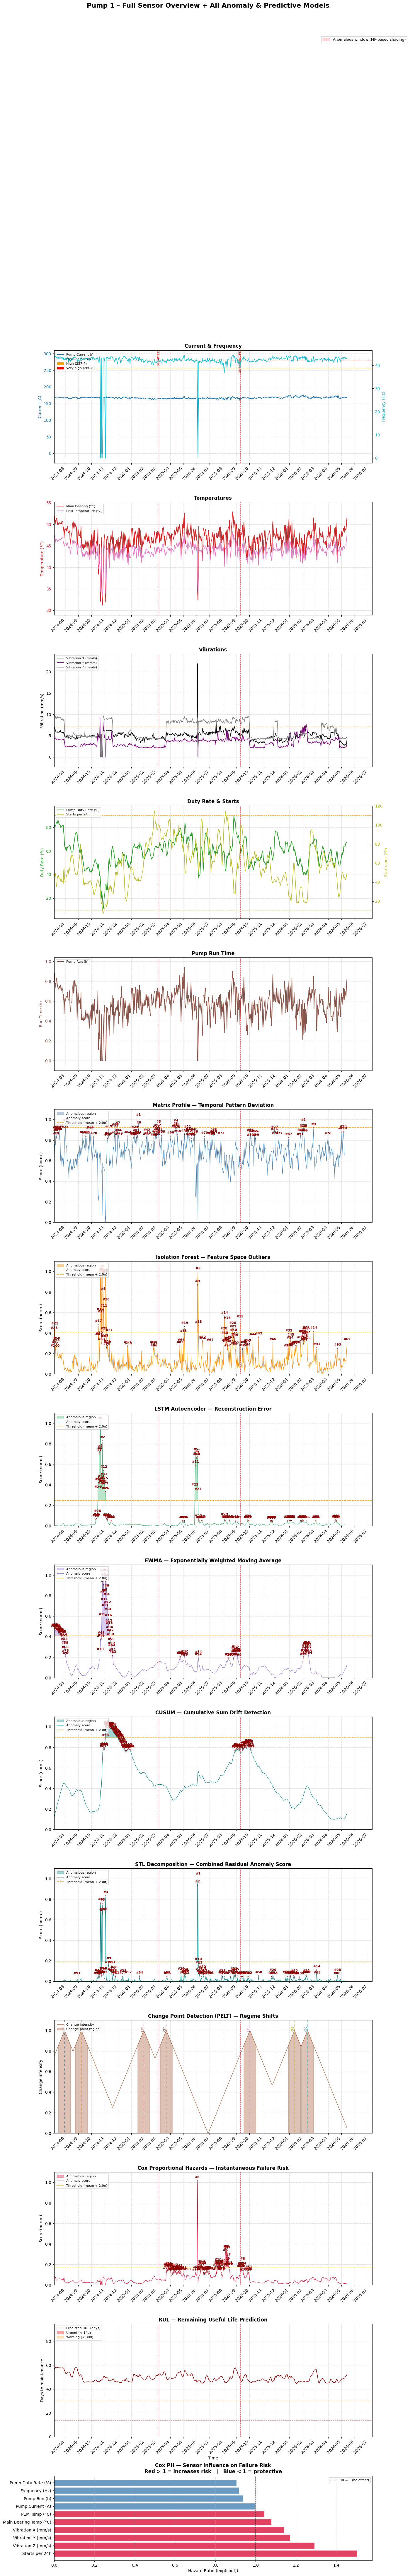

In [ ]:
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime

# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────
def draw_limits(ax, col_name):
    if col_name not in LIMITS:
        return []
    handles, lims = [], LIMITS[col_name]
    if "high" in lims:
        ax.axhline(lims["high"], color="orange", linestyle="--",
                   linewidth=1.0, alpha=0.85, zorder=2)
        handles.append(mpatches.Patch(color="orange", label=f"High ({lims['high']})"))
    if "very_high" in lims:
        ax.axhline(lims["very_high"], color="red", linestyle="--",
                   linewidth=1.0, alpha=0.85, zorder=2)
        handles.append(mpatches.Patch(color="red", label=f"Very high ({lims['very_high']})"))
    return handles

def shade_anomalies(ax, times, score_norm, thresh_norm):
    ylo, yhi = ax.get_ylim()
    ax.fill_between(times, ylo, yhi,
                    where=(score_norm > thresh_norm),
                    color="red", alpha=0.07, zorder=0)

def draw_score_panel(ax, times, score_norm, thresh_norm,
                     disc_idx, disc_times, raw_scores, title, color):
    ax.fill_between(times, score_norm, thresh_norm,
                    where=(score_norm > thresh_norm),
                    color=color, alpha=0.35, label="Anomalous region")
    ax.plot(times, score_norm, color=color, linewidth=0.8, label="Anomaly score")
    ax.axhline(thresh_norm, color="orange", linestyle="--",
               linewidth=1.2, label=f"Threshold (mean + {THRESHOLD_SIGMA}σ)")
    for rank, (idx, t) in enumerate(zip(disc_idx, disc_times)):
        t_nv = (raw_scores[idx] - raw_scores.min()) / \
               (raw_scores.max() - raw_scores.min() + 1e-9)
        ax.annotate(f"#{rank+1}", xy=(t, t_nv), xytext=(0, 10),
                    textcoords="offset points", fontsize=8,
                    color="darkred", fontweight="bold", ha="center",
                    arrowprops=dict(arrowstyle="-", color="darkred", lw=0.8))
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Score (norm.)")
    ax.set_title(title, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(loc="upper left", fontsize=8)

# ─────────────────────────────────────────────────────────────────────────────
# Events
# ─────────────────────────────────────────────────────────────────────────────
events = [
    {"date": datetime(2025, 3, 6), "label": "SHORTED", "color": "red"},
    {"date": datetime(2025, 9, 10), "label": "UNBALANCED",  "color": "red"},
]

# ─────────────────────────────────────────────────────────────────────────────
# Build figure: 14 time-series rows + 1 bar chart row
# ─────────────────────────────────────────────────────────────────────────────
N_TS   = 14
fig    = plt.figure(figsize=(14, 7 * N_TS))
gs     = gridspec.GridSpec(N_TS + 1, 1, figure=fig,
                           height_ratios=[1]*N_TS + [0.75],
                           hspace=0.35)

ts_axes = [fig.add_subplot(gs[i]) for i in range(N_TS)]
ax_bar  = fig.add_subplot(gs[N_TS])   # bar chart — no shared x

# Share x-axis across all time-series panels
for ax in ts_axes[1:]:
    ax.sharex(ts_axes[0])

# ── Event lines across all time-series panels ─────────────────────────────────
for event in events:
    for ax in ts_axes:
        ax.axvline(x=event["date"], color=event["color"],
                   linestyle="--", linewidth=1.0, alpha=0.6, zorder=3)

# ─────────────────────────────────────────────────────────────────────────────
# Panel 1: Current & Frequency
# ─────────────────────────────────────────────────────────────────────────────
ax1      = ts_axes[0]
ax1_twin = ax1.twinx()
line1, = ax1.plot(combined_df[TIME_COL], combined_df[current_col],
                  color="tab:blue", linewidth=1.5, label="Pump Current (A)")
line2, = ax1_twin.plot(combined_df[TIME_COL], combined_df[frequency_col],
                       color="tab:cyan", linewidth=1.2, label="Frequency (Hz)")
ax1.set_ylabel("Current (A)", color="tab:blue")
ax1_twin.set_ylabel("Frequency (Hz)", color="tab:cyan")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1_twin.tick_params(axis="y", labelcolor="tab:cyan")
ax1.grid(True, linestyle="--", alpha=0.4)
ax1.set_title("Current & Frequency", fontweight="bold")
lim_handles = draw_limits(ax1, current_col)
ax1.legend([line1, line2] + lim_handles,
           [h.get_label() for h in [line1, line2] + lim_handles],
           loc="upper left", fontsize=8)

# ─────────────────────────────────────────────────────────────────────────────
# Panel 2: Temperatures
# ─────────────────────────────────────────────────────────────────────────────
ax2 = ts_axes[1]
ax2.plot(combined_df[TIME_COL], combined_df[bearing_col],
         color="tab:red",  linewidth=1.5, label="Main Bearing (°C)")
ax2.plot(combined_df[TIME_COL], combined_df[pem_col],
         color="tab:pink", linewidth=1.2, label="PEM Temperature (°C)")
ax2.set_ylabel("Temperature (°C)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.grid(True, linestyle="--", alpha=0.4)
ax2.set_title("Temperatures", fontweight="bold")
ax2.legend(loc="upper left", fontsize=8)

# ─────────────────────────────────────────────────────────────────────────────
# Panel 3: Vibrations
# ─────────────────────────────────────────────────────────────────────────────
ax3 = ts_axes[2]
ax3.plot(combined_df[TIME_COL], combined_df[vib_x_col],
         color="black",  linewidth=1.2, label="Vibration X (mm/s)")
ax3.plot(combined_df[TIME_COL], combined_df[vib_y_col],
         color="purple", linewidth=1.2, label="Vibration Y (mm/s)")
ax3.plot(combined_df[TIME_COL], combined_df[vib_z_col],
         color="gray",   linewidth=1.2, label="Vibration Z (mm/s)")
ax3.set_ylabel("Vibration (mm/s)")
ax3.grid(True, linestyle="--", alpha=0.4)
ax3.set_title("Vibrations", fontweight="bold")
draw_limits(ax3, vib_x_col)
ax3.legend(loc="upper left", fontsize=8)

# ─────────────────────────────────────────────────────────────────────────────
# Panel 4: Duty Rate & Starts
# ─────────────────────────────────────────────────────────────────────────────
ax4      = ts_axes[3]
ax4_twin = ax4.twinx()
line3, = ax4.plot(combined_df[TIME_COL], combined_df[duty_col],
                  color="tab:green", linewidth=1.5, label="Pump Duty Rate (%)")
line4, = ax4_twin.plot(combined_df[TIME_COL], combined_df[starts_col],
                       color="tab:olive", linewidth=1.2, label="Starts per 24h")
ax4.set_ylabel("Duty Rate (%)", color="tab:green")
ax4_twin.set_ylabel("Starts per 24h", color="tab:olive")
ax4.tick_params(axis="y", labelcolor="tab:green")
ax4_twin.tick_params(axis="y", labelcolor="tab:olive")
ax4.grid(True, linestyle="--", alpha=0.4)
ax4.set_title("Duty Rate & Starts", fontweight="bold")
draw_limits(ax4, duty_col)
draw_limits(ax4_twin, starts_col)
ax4.legend([line3, line4], [line3.get_label(), line4.get_label()],
           loc="upper left", fontsize=8)

# ─────────────────────────────────────────────────────────────────────────────
# Panel 5: Pump Run Time
# ─────────────────────────────────────────────────────────────────────────────
ax5 = ts_axes[4]
ax5.plot(combined_df[TIME_COL], combined_df[pump_run_col],
         color="tab:brown", linewidth=1.5, label="Pump Run (h)")
ax5.set_ylabel("Run Time (h)", color="tab:brown")
ax5.tick_params(axis="y", labelcolor="tab:brown")
ax5.grid(True, linestyle="--", alpha=0.4)
ax5.set_title("Pump Run Time", fontweight="bold")
ax5.legend(loc="upper left", fontsize=8)

# ── Shade anomalies on sensor panels (Matrix Profile as base) ─────────────────
for ax in ts_axes[:5]:
    ax.relim(); ax.autoscale_view()
    shade_anomalies(ax, profile_times, profile_norm, threshold_norm)

# Event label after ylims are set
for event in events:
    ts_axes[0].text(event["date"], ts_axes[0].get_ylim()[1],
                    f" {event['label']}", fontsize=8, color=event["color"],
                    rotation=90, va="top", ha="center")

# ─────────────────────────────────────────────────────────────────────────────
# Panel 6: Matrix Profile
# ─────────────────────────────────────────────────────────────────────────────
draw_score_panel(ts_axes[5], profile_times, profile_norm, threshold_norm,
                 discord_indices, discord_times, combined_profile,
                 "Matrix Profile — Temporal Pattern Deviation", "steelblue")

# ─────────────────────────────────────────────────────────────────────────────
# Panel 7: Isolation Forest
# ─────────────────────────────────────────────────────────────────────────────
draw_score_panel(ts_axes[6], if_times, if_norm, threshold_if_norm,
                 discord_indices_if, discord_times_if, if_raw_scores,
                 "Isolation Forest — Feature Space Outliers", "darkorange")

# ─────────────────────────────────────────────────────────────────────────────
# Panel 8: LSTM Autoencoder
# ─────────────────────────────────────────────────────────────────────────────
draw_score_panel(ts_axes[7], lstm_times, lstm_norm, threshold_lstm_norm,
                 discord_indices_lstm, discord_times_lstm, recon_errors,
                 "LSTM Autoencoder — Reconstruction Error", "mediumseagreen")

# ─────────────────────────────────────────────────────────────────────────────
# Panel 9: EWMA
# ─────────────────────────────────────────────────────────────────────────────
draw_score_panel(ts_axes[8], spc_times, ewma_norm, threshold_ewma_norm,
                 discord_indices_ewma, discord_times_ewma, ewma_combined,
                 "EWMA — Exponentially Weighted Moving Average", "mediumpurple")

# ─────────────────────────────────────────────────────────────────────────────
# Panel 10: CUSUM
# ─────────────────────────────────────────────────────────────────────────────
draw_score_panel(ts_axes[9], spc_times, cusum_norm, threshold_cusum_norm,
                 discord_indices_cusum, discord_times_cusum, cusum_combined,
                 "CUSUM — Cumulative Sum Drift Detection", "teal")

# ─────────────────────────────────────────────────────────────────────────────
# Panel 11: STL Decomposition
# ─────────────────────────────────────────────────────────────────────────────
draw_score_panel(ts_axes[10], stl_times, stl_norm, threshold_stl_norm,
                 discord_indices_stl, discord_times_stl, stl_combined,
                 "STL Decomposition — Combined Residual Anomaly Score", "darkcyan")

# ─────────────────────────────────────────────────────────────────────────────
# Panel 12: Change Point Detection
# ─────────────────────────────────────────────────────────────────────────────
ax12 = ts_axes[11]
ax12.plot(cp_times, cp_norm, color="sienna", linewidth=0.8, label="Change intensity")
ax12.fill_between(cp_times, 0, cp_norm,
                  where=(cp_norm > threshold_cp_norm),
                  color="sienna", alpha=0.35, label="Change point region")
cp_colours = plt.cm.tab10(np.linspace(0, 1, len(breakpoint_indices)))
for i, (bp_idx, t) in enumerate(zip(breakpoint_indices, breakpoint_times)):
    ax12.axvline(x=t, color=cp_colours[i], linestyle=":", linewidth=1.2, alpha=0.9)
    ax12.text(t, 0.95, f"CP{i+1}", fontsize=7, color=cp_colours[i],
              rotation=90, va="top", ha="right",
              transform=ax12.get_xaxis_transform())
ax12.set_ylim(0, 1.1)
ax12.set_ylabel("Change intensity")
ax12.set_title("Change Point Detection (PELT) — Regime Shifts", fontweight="bold")
ax12.grid(True, linestyle="--", alpha=0.4)
ax12.legend(loc="upper left", fontsize=8)

# ─────────────────────────────────────────────────────────────────────────────
# Panel 13: Cox PH Risk Score
# ─────────────────────────────────────────────────────────────────────────────
draw_score_panel(ts_axes[12], cox_plot_times, cox_norm, threshold_cox_norm,
                 discord_indices_cox, discord_times_cox, cox_risk_score,
                 "Cox Proportional Hazards — Instantaneous Failure Risk", "crimson")

# ─────────────────────────────────────────────────────────────────────────────
# Panel 14: RUL
# ─────────────────────────────────────────────────────────────────────────────
ax14 = ts_axes[13]
ax14.plot(rul_times, rul_pred_days,
          color="darkred", linewidth=1.2, label="Predicted RUL (days)")
ax14.fill_between(rul_times, 0, rul_pred_days,
                  where=(rul_pred_days < ALERT_RED),
                  color="red", alpha=0.35, label=f"Urgent (< {ALERT_RED}d)")
ax14.fill_between(rul_times, 0, rul_pred_days,
                  where=((rul_pred_days >= ALERT_RED) & (rul_pred_days < ALERT_ORANGE)),
                  color="orange", alpha=0.3, label=f"Warning (< {ALERT_ORANGE}d)")
ax14.axhline(ALERT_RED,    color="red",    linestyle="--", linewidth=1.0, alpha=0.7)
ax14.axhline(ALERT_ORANGE, color="orange", linestyle="--", linewidth=1.0, alpha=0.7)
ax14.set_ylim(0, RUL_MAX * 1.05)
ax14.set_ylabel("Days to maintenance")
ax14.set_title("RUL — Remaining Useful Life Prediction", fontweight="bold")
ax14.grid(True, linestyle="--", alpha=0.4)
ax14.legend(loc="upper left", fontsize=8)

# ─────────────────────────────────────────────────────────────────────────────
# X-axis formatting — apply to ALL time-series panels + bar chart
# ─────────────────────────────────────────────────────────────────────────────
for ax in ts_axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.tick_params(axis="x", labelbottom=True, rotation=45)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

# Adjust x-axis limits to follow RUL (applied to shared master)
x_min = pd.to_datetime(rul_times.min())
x_max = pd.to_datetime(rul_times.max()) + pd.Timedelta(days=rul_pred_days.max())
ts_axes[0].set_xlim(x_min, x_max)

# Set xlabel only on the last time-series panel
ts_axes[-1].set_xlabel("Time")

# ─────────────────────────────────────────────────────────────────────────────
# Panel 15: Cox PH sensor influence bar chart
# ─────────────────────────────────────────────────────────────────────────────
colors_bar = ["crimson" if hr > 1 else "steelblue"
              for hr in coef_df["hazard_ratio"]]
ax_bar.barh(coef_df["Sensor"], coef_df["hazard_ratio"],
            color=colors_bar, alpha=0.8, edgecolor="white")
ax_bar.axvline(1.0, color="black", linestyle="--", linewidth=1.0,
               label="HR = 1 (no effect)")
ax_bar.set_xlabel("Hazard Ratio (exp(coef))")
ax_bar.set_title("Cox PH — Sensor Influence on Failure Risk\n"
                 "Red > 1 = increases risk   |   Blue < 1 = protective",
                 fontweight="bold")
ax_bar.legend(fontsize=8)
ax_bar.grid(True, axis="x", linestyle="--", alpha=0.4)

# ─────────────────────────────────────────────────────────────────────────────
# Global legend & title
# ─────────────────────────────────────────────────────────────────────────────
fig.legend(
    handles=[mpatches.Patch(color="red", alpha=0.15,
                            label="Anomalous window (MP-based shading)")],
    loc="upper right", bbox_to_anchor=(0.99, 0.99), fontsize=9
)
fig.suptitle("Pump 1 – Full Sensor Overview + All Anomaly & Predictive Models",
             fontsize=16, fontweight="bold", y=1.001)



plt.show()